In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
import numpy as np
import re
import string
import os
from google.colab import drive

df1_path = "/content/drive/MyDrive/FYP/Suicide_Detection.csv"
df2_path = "/content/drive/MyDrive/FYP/suicide_only_clean.csv"

def load_and_standardize_data(path1, path2):
    if not os.path.exists(path1) or not os.path.exists(path2):
        print(f"Error: One or both files not found.\nPath 1: {path1}\nPath 2: {path2}")
        return None

    print("Loading Suicide_Detection.csv (DF1)...")
    df1 = pd.read_csv(path1)
    df1 = df1.rename(columns={'class': 'label'})
    df1['label'] = df1['label'].map({'suicide': 1, 'non-suicide': 0})
    df1 = df1[['text', 'label']]

    print("Loading suicide_only_clean.csv (DF2)...")
    df2 = pd.read_csv(path2)
    df2 = df2[['text']]
    df2['label'] = 1 

    df = pd.concat([df1, df2], ignore_index=True)
    df = df.dropna(subset=['text', 'label'])
    return df

df = load_and_standardize_data(df1_path, df2_path)
if df is not None:
    print(f"Total samples: {len(df)}")
    print(f"Class distribution:\n{df['label'].value_counts()}")

Loading Suicide_Detection.csv (DF1)...
Loading suicide_only_clean.csv (DF2)...
Total samples: 242066
Class distribution:
label
1    126029
0    116037
Name: count, dtype: int64


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 1. Text Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#','', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Preprocessing text...")
df['clean_text'] = df['text'].apply(clean_text)

max_words = 20000
max_len = 250

tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=max_len)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Preprocessing text...


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = 20000
embedding_dim = 128
lstm_units = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SpatialDropout1D(0.2),
    # Set recurrent_dropout=0 for CuDNN (GPU) acceleration
    LSTM(lstm_units, dropout=0.2, recurrent_dropout=0),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
681/681 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9145 - loss: 0.2241 - val_accuracy: 0.9399 - val_loss: 0.1626
Epoch 2/10
681/681 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9454 - loss: 0.1520 - val_accuracy: 0.9426 - val_loss: 0.1565
Epoch 3/10
681/681 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9526 - loss: 0.1323 - val_accuracy: 0.9386 - val_loss: 0.1640
Epoch 4/10
681/681 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9577 - loss: 0.1177 - val_accuracy: 0.9396 - val_loss: 0.1635
Epoch 5/10
681/681 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9622 - loss: 0.1046 - val_accuracy: 0.9381 - val_loss: 0.1745
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9431 - loss: 0.1573
Test Accuracy: 0.9431


Generating predictions...
1513/1513 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step

Classification Report:
              precision    recall  f1-score   support

 Non-Suicide       0.95      0.93      0.94     23208
     Suicide       0.94      0.95      0.95     25206

    accuracy                           0.94     48414
   macro avg       0.94      0.94      0.94     48414
weighted avg       0.94      0.94      0.94     48414



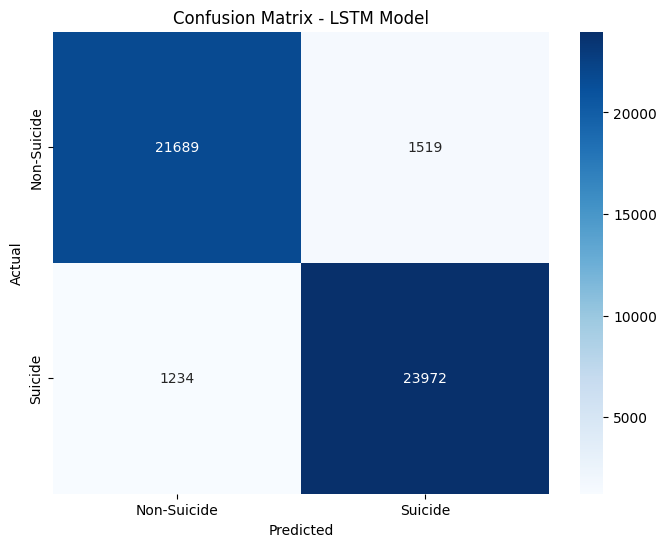

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Generating predictions...")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Suicide', 'Suicide']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Suicide', 'Suicide'], 
            yticklabels=['Non-Suicide', 'Suicide'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LSTM Model')
plt.show()